# Appearance and Domain-Robustness Forensics

This notebook diagnoses why the same model/loss family behaves oppositely on
validation volumes 104 and 116 before another training change is attempted.

It compares training and validation CT appearance inside verified liver and
tumor masks, connects domain-shift measurements to saved patient Dice, identifies
nearest training analogues, and produces a gated recommendation.

**The test split is never loaded or inspected.**


## tl;dr

The stabilized composite loss recovered volume 116 from approximately zero to
**0.0515**, but volume 104 collapsed from the baseline **0.1976** to **0.0050**.
Mean patient Dice remained below the Focal-Dice baseline.

The next decision is therefore diagnostic:

- If volumes 104 or 116 are appearance outliers, test robust intensity
  normalization/augmentation.
- If they are not appearance outliers, move to spatial context such as 2.5D
  adjacent-slice input rather than another loss adjustment.


## Context & Methods

### Key assumptions

- Dataset provenance, orientation, mask semantics and splits are already frozen.
- Validation labels may be used for diagnosis and model selection; test data may
  not be accessed.
- Patient-level appearance is measured from a deterministic bounded slice sample.
- HU values are reconstructed from the frozen `HU[-160,240]` 8-bit PNG profile.
- Domain-shift scores are descriptive and do not establish causality.


In [1]:
from __future__ import annotations

from pathlib import Path
from IPython.display import display
import hashlib
import json
import math
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path(r"D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver")
DATASET_ROOT = Path(
    r"D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\02_staging"
    r"\build_corrected_20260713_214847_v2"
)
MANIFEST_PATH = DATASET_ROOT / "manifests" / "slice_manifest.csv"
BASELINE_OUTPUT_DIR = PROJECT_ROOT / "Practice" / "patient_aware_baseline_outputs"
COMPOSITE_OUTPUT_DIR = PROJECT_ROOT / "Practice" / "stabilized_composite_loss_outputs"
OUTPUT_DIR = PROJECT_ROOT / "Practice" / "appearance_domain_forensics_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_MANIFEST_SHA256 = (
    "575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889"
)
MAX_ORGAN_SLICES_PER_VOLUME = 16
MAX_TUMOR_SLICES_PER_VOLUME = 16
PIXEL_SUBSAMPLE_STEP = 4
HU_MIN, HU_MAX = -160.0, 240.0
RANDOM_SEED = 42

print(f"Output directory: {OUTPUT_DIR}")
print("Test split policy: locked and excluded")


Output directory: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\Practice\appearance_domain_forensics_outputs
Test split policy: locked and excluded


## Data

### 1. Verify the manifest and lock the allowed population

In [2]:
manifest_hash = hashlib.sha256(MANIFEST_PATH.read_bytes()).hexdigest()
if manifest_hash != EXPECTED_MANIFEST_SHA256:
    raise RuntimeError(f"Manifest hash changed: {manifest_hash}")

manifest = pd.read_csv(MANIFEST_PATH)
required = {
    "sample_id", "volume_id", "slice_index", "image_path",
    "organ_mask_path", "tumor_mask_path", "organ_pixels", "tumor_pixels",
    "split", "verification_status", "automatic_integrity_pass",
    "manual_spatial_status", "exclusion_reason",
}
missing = required - set(manifest.columns)
if missing:
    raise ValueError(f"Manifest columns missing: {sorted(missing)}")

eligible = manifest.loc[
    manifest["split"].isin(["train", "val"])
    & manifest["verification_status"].eq("verified")
    & manifest["automatic_integrity_pass"].astype(bool)
    & manifest["manual_spatial_status"].eq("approved")
    & manifest["exclusion_reason"].isna()
].copy()
if eligible["split"].eq("test").any():
    raise RuntimeError("Test rows entered the diagnostic population.")
if eligible["sample_id"].duplicated().any():
    raise RuntimeError("Duplicate sample IDs detected.")

split_audit = eligible.groupby("split").agg(
    slices=("sample_id", "size"),
    volumes=("volume_id", "nunique"),
    tumor_positive_slices=("tumor_pixels", lambda values: int((values > 0).sum())),
)
display(split_audit)
print(f"Manifest SHA256: {manifest_hash}")


,slices,volumes,tumor_positive_slices
split,,,
train,40667,104,4930
val,10685,13,1042


Manifest SHA256: 575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889


### 2. Select a deterministic bounded slice sample

In [3]:
def evenly_spaced_rows(frame: pd.DataFrame, maximum: int) -> pd.DataFrame:
    frame = frame.sort_values("slice_index")
    if len(frame) <= maximum:
        return frame
    positions = np.linspace(0, len(frame) - 1, maximum).round().astype(int)
    return frame.iloc[np.unique(positions)]


selected_groups = []
for (split, volume_id), group in eligible.groupby(["split", "volume_id"], sort=True):
    organ_rows = evenly_spaced_rows(group.loc[group["organ_pixels"].gt(0)], MAX_ORGAN_SLICES_PER_VOLUME)
    tumor_rows = evenly_spaced_rows(group.loc[group["tumor_pixels"].gt(0)], MAX_TUMOR_SLICES_PER_VOLUME)
    selected = (
        pd.concat([organ_rows, tumor_rows], ignore_index=False)
        .drop_duplicates("sample_id")
        .sort_values("slice_index")
    )
    selected_groups.append(selected)

sampled_manifest = pd.concat(selected_groups, ignore_index=True)
sampling_audit = sampled_manifest.groupby(["split", "volume_id"]).agg(
    sampled_slices=("sample_id", "size"),
    sampled_tumor_slices=("tumor_pixels", lambda values: int((values > 0).sum())),
)
display(sampling_audit.groupby("split").agg(
    volumes=("sampled_slices", "size"),
    median_slices=("sampled_slices", "median"),
    maximum_slices=("sampled_slices", "max"),
))
print(f"Bounded sample: {len(sampled_manifest):,} slices")


,volumes,median_slices,maximum_slices
split,,,
train,104,28.5,32
val,13,30.0,31


Bounded sample: 3,106 slices


## Results

### 3. Extract volume-level HU and contrast features

In [4]:
def resolve_path(value: str) -> Path:
    return DATASET_ROOT / Path(str(value))


def read_grayscale(path: Path) -> np.ndarray:
    with Image.open(path) as image:
        return np.asarray(image.convert("L"), dtype=np.uint8)


def png_to_hu(image: np.ndarray) -> np.ndarray:
    return HU_MIN + image.astype(np.float32) * (HU_MAX - HU_MIN) / 255.0


def summarize(values: np.ndarray, prefix: str) -> dict:
    if values.size == 0:
        return {
            f"{prefix}_mean": np.nan, f"{prefix}_std": np.nan,
            f"{prefix}_p10": np.nan, f"{prefix}_p50": np.nan,
            f"{prefix}_p90": np.nan,
        }
    return {
        f"{prefix}_mean": float(np.mean(values)),
        f"{prefix}_std": float(np.std(values)),
        f"{prefix}_p10": float(np.percentile(values, 10)),
        f"{prefix}_p50": float(np.percentile(values, 50)),
        f"{prefix}_p90": float(np.percentile(values, 90)),
    }


volume_rows, pixel_store = [], {}
for (split, volume_id), group in sampled_manifest.groupby(["split", "volume_id"], sort=True):
    liver_values, tumor_values = [], []
    for row in group.itertuples(index=False):
        image_hu = png_to_hu(read_grayscale(resolve_path(row.image_path)))
        organ = read_grayscale(resolve_path(row.organ_mask_path)) > 0
        tumor = read_grayscale(resolve_path(row.tumor_mask_path)) > 0
        liver_non_tumor = organ & ~tumor
        if liver_non_tumor.any():
            liver_values.append(image_hu[liver_non_tumor][::PIXEL_SUBSAMPLE_STEP])
        if tumor.any():
            tumor_values.append(image_hu[tumor][::PIXEL_SUBSAMPLE_STEP])

    liver = np.concatenate(liver_values) if liver_values else np.array([], dtype=np.float32)
    tumor = np.concatenate(tumor_values) if tumor_values else np.array([], dtype=np.float32)
    pixel_store[(split, int(volume_id))] = {"liver": liver, "tumor": tumor}
    record = {
        "split": split, "volume_id": int(volume_id),
        "sampled_slices": len(group),
        "manifest_tumor_pixels": int(group["tumor_pixels"].sum()),
        **summarize(liver, "liver"),
        **summarize(tumor, "tumor"),
    }
    record["tumor_liver_contrast"] = record["tumor_mean"] - record["liver_mean"]
    record["tumor_to_liver_std_ratio"] = record["tumor_std"] / max(record["liver_std"], 1e-6)
    volume_rows.append(record)

volume_features = pd.DataFrame(volume_rows)
volume_features.to_csv(OUTPUT_DIR / "volume_appearance_features.csv", index=False)
display(volume_features.groupby("split").agg(
    volumes=("volume_id", "size"),
    liver_mean=("liver_mean", "mean"),
    liver_std=("liver_std", "mean"),
    tumor_mean=("tumor_mean", "mean"),
    contrast=("tumor_liver_contrast", "mean"),
))


,volumes,liver_mean,liver_std,tumor_mean,contrast
split,,,,,
train,104,100.319476,21.188312,67.022526,-32.693189
val,13,108.187405,20.645429,62.894282,-46.409296


### 4. Compute training-reference shift scores and nearest analogues

In [5]:
feature_columns = [
    "liver_mean", "liver_std", "liver_p10", "liver_p50", "liver_p90",
    "tumor_mean", "tumor_std", "tumor_p10", "tumor_p50", "tumor_p90",
    "tumor_liver_contrast", "tumor_to_liver_std_ratio",
]
training = volume_features.loc[volume_features["split"].eq("train")].copy()
validation = volume_features.loc[volume_features["split"].eq("val")].copy()

training_medians = training[feature_columns].median()
training_matrix = training[feature_columns].fillna(training_medians)
validation_matrix = validation[feature_columns].fillna(training_medians)

scaler = StandardScaler().fit(training_matrix)
train_scaled = scaler.transform(training_matrix)
val_scaled = scaler.transform(validation_matrix)
pca = PCA(n_components=2, random_state=RANDOM_SEED).fit(train_scaled)

training[["pc1", "pc2"]] = pca.transform(train_scaled)
validation[["pc1", "pc2"]] = pca.transform(val_scaled)
training["shift_score"] = np.sqrt(np.square(train_scaled).sum(axis=1))
validation["shift_score"] = np.sqrt(np.square(val_scaled).sum(axis=1))
shift_threshold = float(training["shift_score"].quantile(0.95))
validation["appearance_outlier"] = validation["shift_score"].gt(shift_threshold)

nearest_rows = []
for validation_index, validation_row in validation.iterrows():
    vector = val_scaled[validation.index.get_loc(validation_index)]
    distances = np.sqrt(np.square(train_scaled - vector).sum(axis=1))
    order = np.argsort(distances)[:3]
    for rank, position in enumerate(order, start=1):
        nearest_rows.append({
            "validation_volume": int(validation_row["volume_id"]),
            "rank": rank,
            "training_volume": int(training.iloc[position]["volume_id"]),
            "standardized_distance": float(distances[position]),
        })
nearest = pd.DataFrame(nearest_rows)
nearest.to_csv(OUTPUT_DIR / "nearest_training_analogues.csv", index=False)

display(validation[[
    "volume_id", "shift_score", "appearance_outlier",
    "liver_mean", "tumor_mean", "tumor_liver_contrast",
]].sort_values("shift_score", ascending=False))
print(f"Training-reference 95th-percentile shift threshold: {shift_threshold:.3f}")


,volume_id,shift_score,appearance_outlier,liver_mean,tumor_mean,tumor_liver_contrast
104,104,6.676830,True,96.877388,10.174591,-86.702797
109,109,5.064833,False,83.367645,23.133520,-60.234125
112,112,4.791121,False,138.750259,65.574226,-73.176033
107,107,4.266008,False,123.012878,99.194595,-23.818283
110,110,4.006693,False,129.970551,93.665276,-36.305275
116,116,3.739819,False,66.993454,57.444599,-9.548855
111,111,2.894348,False,126.085526,75.000000,-51.085526
115,115,2.425412,False,125.464760,NaN,NaN
113,113,2.366658,False,117.382454,80.756104,-36.626350
106,106,1.506273,False,105.414627,NaN,NaN


Training-reference 95th-percentile shift threshold: 6.402


### 5. Connect appearance shift to saved patient performance

In [6]:
baseline_patients = pd.read_csv(
    BASELINE_OUTPUT_DIR / "best_validation_patient_metrics.csv"
)[["volume_id", "micro_dice"]].rename(columns={"micro_dice": "baseline_dice"})
composite_patients = pd.read_csv(
    COMPOSITE_OUTPUT_DIR / "best_validation_patient_metrics.csv"
)[["volume_id", "micro_dice"]].rename(columns={"micro_dice": "composite_dice"})

analysis = (
    validation.merge(baseline_patients, on="volume_id", how="left")
    .merge(composite_patients, on="volume_id", how="left")
)
analysis["dice_change"] = analysis["composite_dice"] - analysis["baseline_dice"]
analysis.to_csv(OUTPUT_DIR / "appearance_performance_analysis.csv", index=False)

correlations = pd.DataFrame([
    {
        "relationship": "shift vs baseline Dice",
        "spearman": analysis["shift_score"].corr(analysis["baseline_dice"], method="spearman"),
    },
    {
        "relationship": "shift vs composite Dice",
        "spearman": analysis["shift_score"].corr(analysis["composite_dice"], method="spearman"),
    },
    {
        "relationship": "contrast vs Dice change",
        "spearman": analysis["tumor_liver_contrast"].corr(analysis["dice_change"], method="spearman"),
    },
])
display(correlations.style.format({"spearman": "{:.3f}"}))
display(analysis.sort_values("baseline_dice")[[
    "volume_id", "shift_score", "appearance_outlier",
    "tumor_liver_contrast", "baseline_dice", "composite_dice", "dice_change",
]])


,relationship,spearman
0,shift vs baseline Dice,0.231
1,shift vs composite Dice,0.159
2,contrast vs Dice change,0.800


,volume_id,shift_score,appearance_outlier,tumor_liver_contrast,baseline_dice,composite_dice,dice_change
12,116,3.739819,False,-9.548855,6.412394e-12,5.148114e-02,5.148114e-02
11,115,2.425412,False,NaN,3.816794e-10,4.389816e-10,5.730217e-11
1,105,1.322646,False,NaN,4.755112e-10,1.116071e-09,6.405603e-10
2,106,1.506273,False,NaN,5.434783e-10,7.457122e-10,2.022339e-10
10,114,0.716530,False,NaN,1.063830e-08,3.571428e-08,2.507599e-08
3,107,4.266008,False,-23.818283,8.565866e-02,2.064347e-01,1.207760e-01
0,104,6.676830,True,-86.702797,1.976130e-01,5.004905e-03,-1.926081e-01
7,111,2.894348,False,-51.085526,2.607674e-01,2.931369e-01,3.236945e-02
8,112,4.791121,False,-73.176033,3.425926e-01,1.783518e-02,-3.247574e-01
9,113,2.366658,False,-36.626350,5.237083e-01,5.135602e-01,-1.014804e-02


### 6. Visualize domain position, shift ranking, and performance

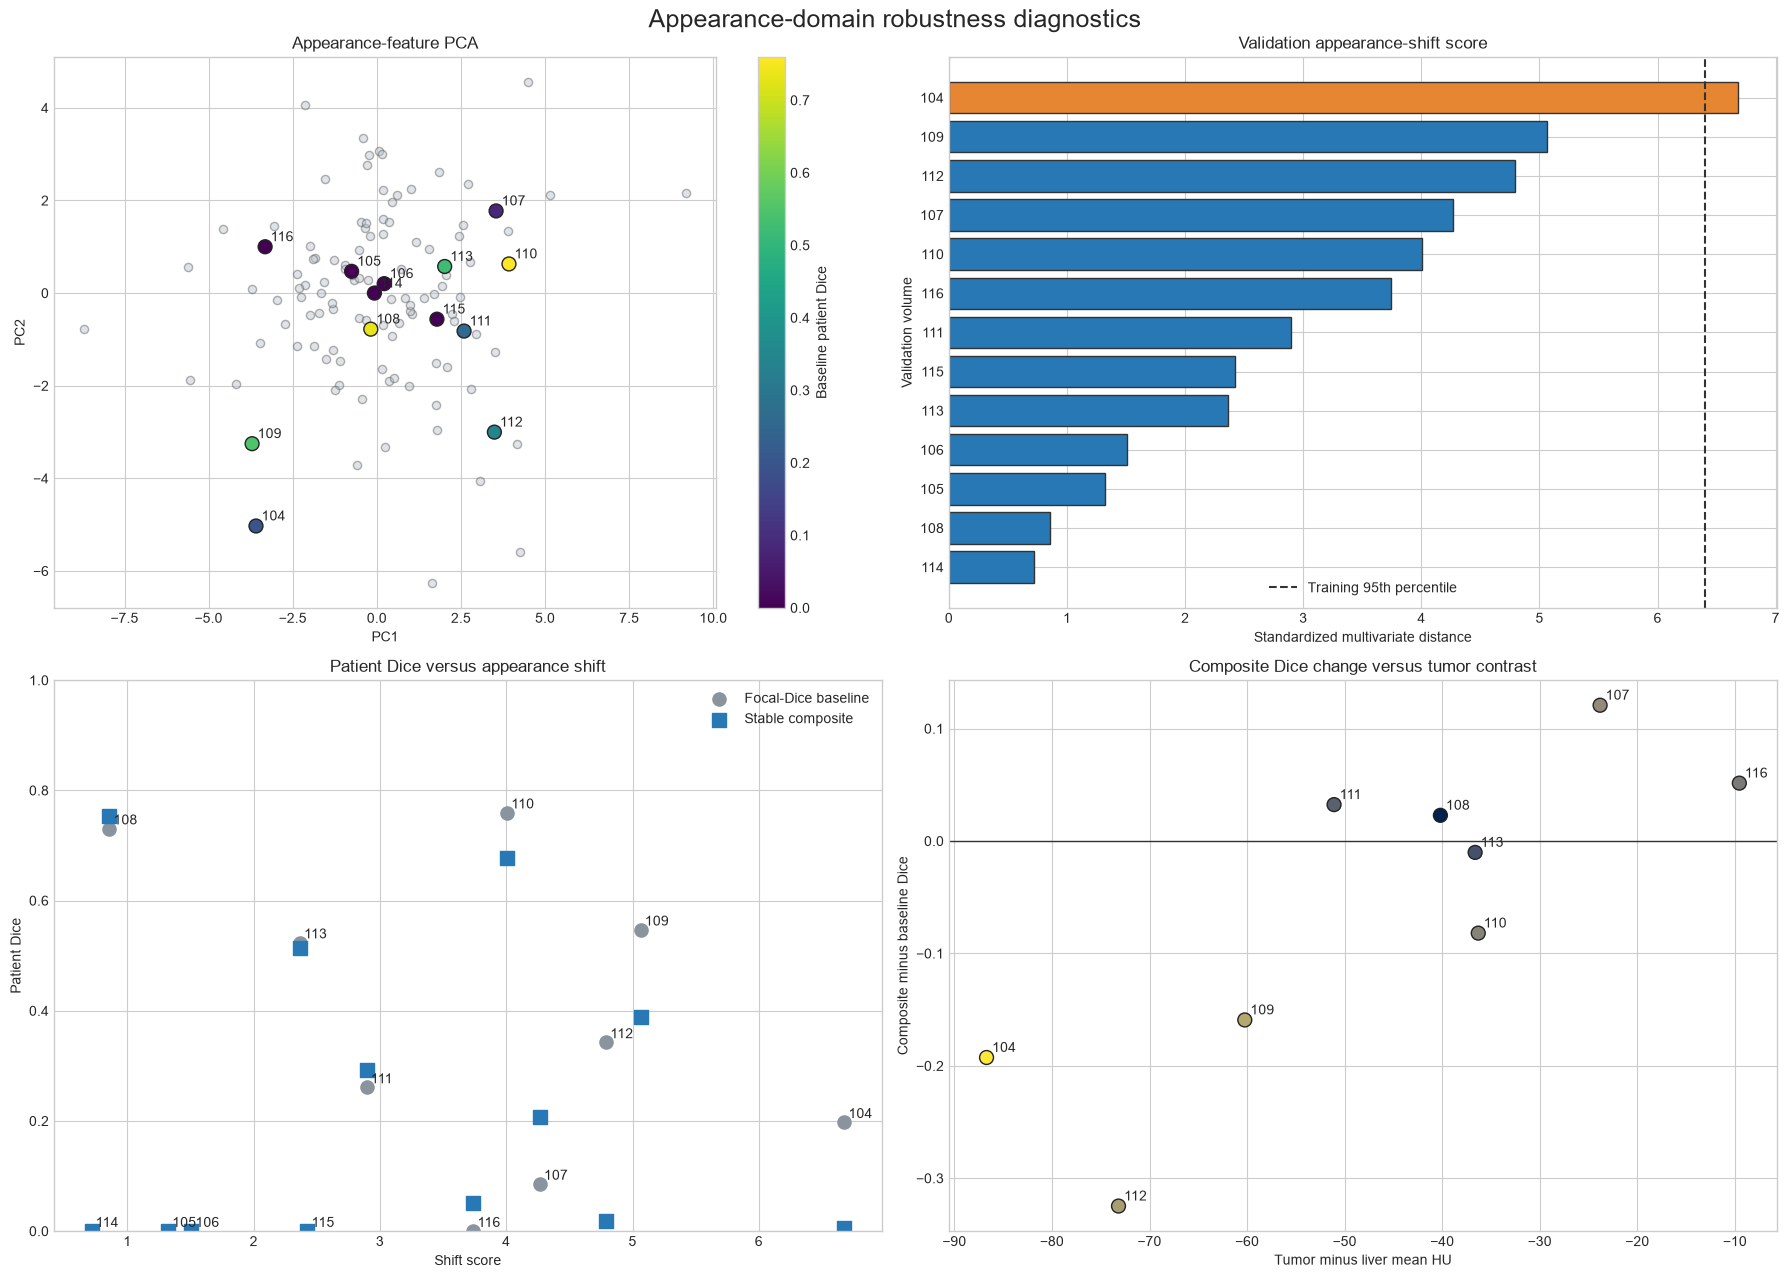

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))

axes[0, 0].scatter(
    training["pc1"], training["pc2"], s=35, alpha=0.45,
    color="#B9C2CC", edgecolor="#555555", label="Training volumes",
)
scatter = axes[0, 0].scatter(
    analysis["pc1"], analysis["pc2"], s=100,
    c=analysis["baseline_dice"], cmap="viridis", edgecolor="#222222",
    label="Validation volumes",
)
for row in analysis.itertuples():
    axes[0, 0].annotate(str(row.volume_id), (row.pc1, row.pc2), xytext=(4, 4), textcoords="offset points")
axes[0, 0].set_title("Appearance-feature PCA")
axes[0, 0].set_xlabel("PC1"); axes[0, 0].set_ylabel("PC2")
fig.colorbar(scatter, ax=axes[0, 0], label="Baseline patient Dice")

ranked = analysis.sort_values("shift_score")
axes[0, 1].barh(
    ranked["volume_id"].astype(str), ranked["shift_score"],
    color=np.where(ranked["appearance_outlier"], "#E68632", "#2878B5"),
    edgecolor="#333333",
)
axes[0, 1].axvline(shift_threshold, linestyle="--", color="#333333", label="Training 95th percentile")
axes[0, 1].set_title("Validation appearance-shift score")
axes[0, 1].set_xlabel("Standardized multivariate distance")
axes[0, 1].set_ylabel("Validation volume"); axes[0, 1].legend()

axes[1, 0].scatter(
    analysis["shift_score"], analysis["baseline_dice"],
    s=90, color="#8A949E", marker="o", label="Focal-Dice baseline",
)
axes[1, 0].scatter(
    analysis["shift_score"], analysis["composite_dice"],
    s=90, color="#2878B5", marker="s", label="Stable composite",
)
for row in analysis.itertuples():
    axes[1, 0].annotate(str(row.volume_id), (row.shift_score, row.baseline_dice), xytext=(3, 3), textcoords="offset points")
axes[1, 0].set_title("Patient Dice versus appearance shift")
axes[1, 0].set_xlabel("Shift score"); axes[1, 0].set_ylabel("Patient Dice")
axes[1, 0].set_ylim(0, 1); axes[1, 0].legend()

axes[1, 1].scatter(
    analysis["tumor_liver_contrast"], analysis["dice_change"],
    s=100, c=analysis["shift_score"], cmap="cividis", edgecolor="#222222",
)
axes[1, 1].axhline(0, color="#333333", linewidth=1)
for row in analysis.itertuples():
    axes[1, 1].annotate(str(row.volume_id), (row.tumor_liver_contrast, row.dice_change), xytext=(4, 4), textcoords="offset points")
axes[1, 1].set_title("Composite Dice change versus tumor contrast")
axes[1, 1].set_xlabel("Tumor minus liver mean HU")
axes[1, 1].set_ylabel("Composite minus baseline Dice")

fig.suptitle("Appearance-domain robustness diagnostics", fontsize=18)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "appearance_domain_dashboard.png", dpi=170, bbox_inches="tight")
plt.show()


### 7. Compare volumes 104 and 116 with nearest training analogues

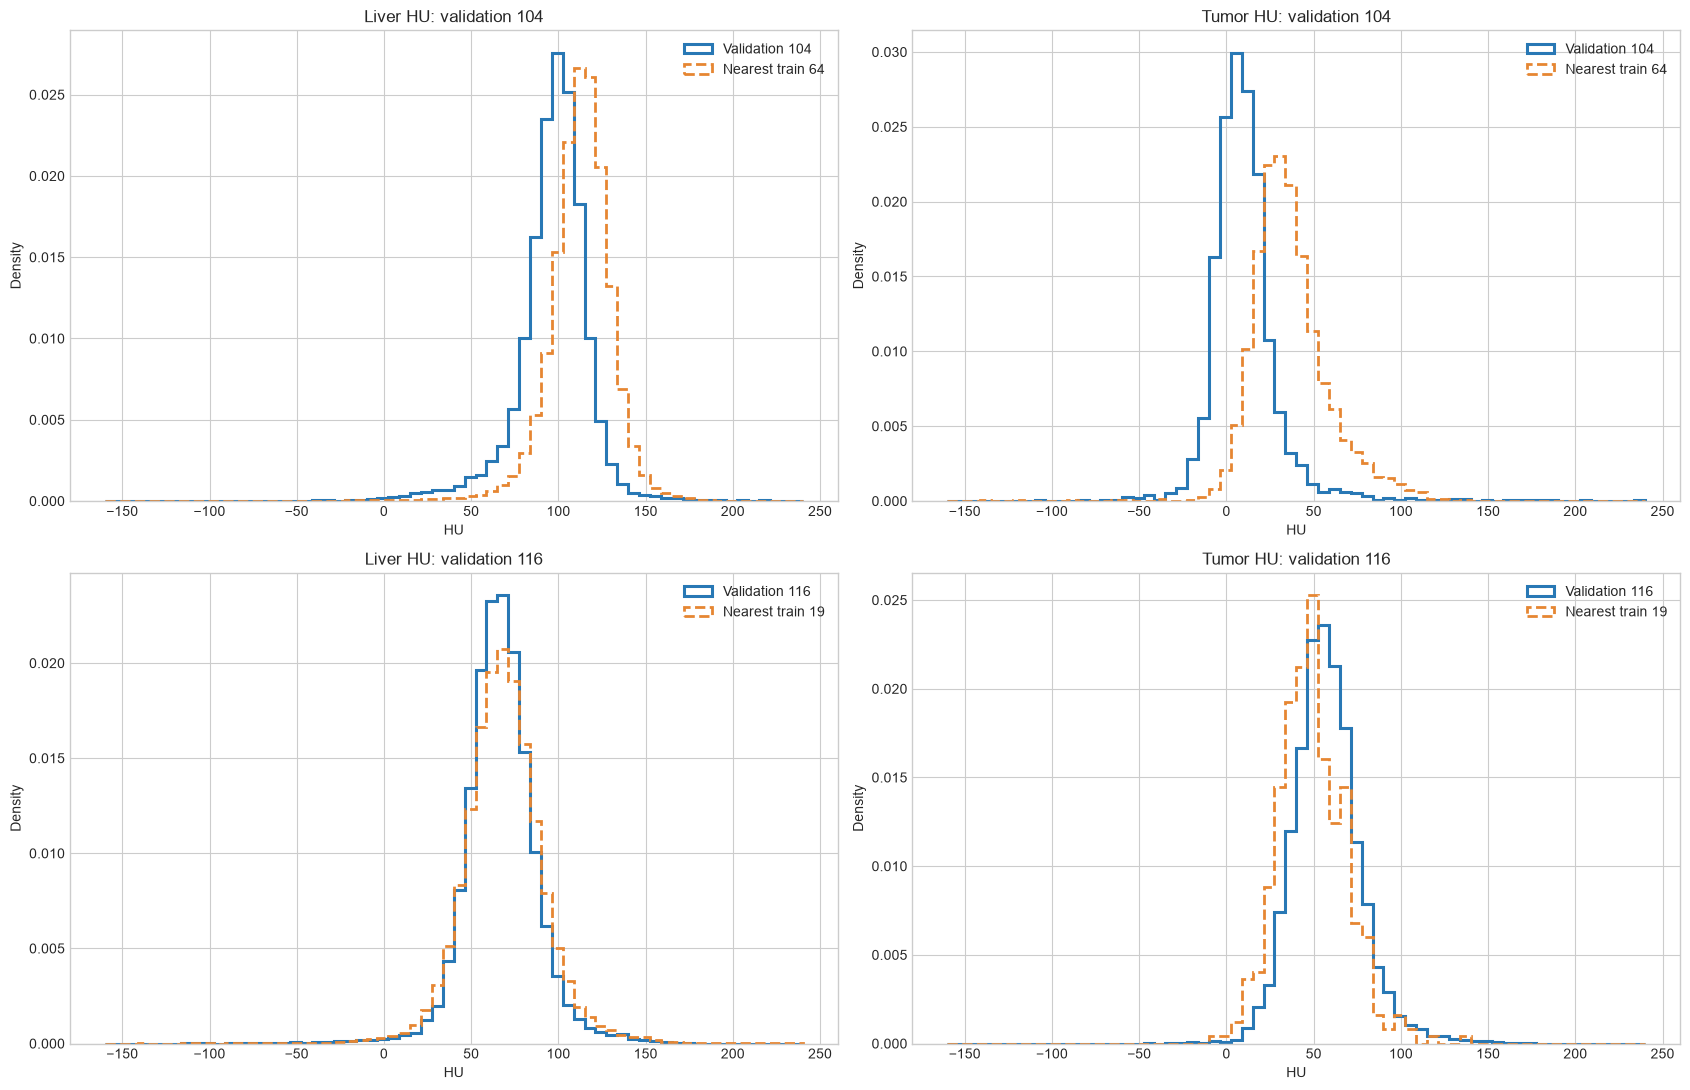

,validation_volume,rank,training_volume,standardized_distance
0,104,1,64,3.475223
1,104,2,95,4.006778
2,104,3,93,4.050286
36,116,1,19,1.352449
37,116,2,11,1.508425
38,116,3,32,1.901199


In [8]:
focus_volumes = [104, 116]
fig, axes = plt.subplots(2, 2, figsize=(17, 11))
histogram_bins = np.linspace(HU_MIN, HU_MAX, 65)

for row_index, validation_volume in enumerate(focus_volumes):
    nearest_volume = int(
        nearest.loc[
            nearest["validation_volume"].eq(validation_volume)
            & nearest["rank"].eq(1),
            "training_volume",
        ].iloc[0]
    )
    for tissue, axis in [("liver", axes[row_index, 0]), ("tumor", axes[row_index, 1])]:
        validation_values = pixel_store[("val", validation_volume)][tissue]
        training_values = pixel_store[("train", nearest_volume)][tissue]
        if validation_values.size:
            axis.hist(
                validation_values, bins=histogram_bins, density=True,
                histtype="step", linewidth=2.2, color="#2878B5",
                label=f"Validation {validation_volume}",
            )
        if training_values.size:
            axis.hist(
                training_values, bins=histogram_bins, density=True,
                histtype="step", linewidth=2.0, linestyle="--", color="#E68632",
                label=f"Nearest train {nearest_volume}",
            )
        axis.set_title(f"{tissue.title()} HU: validation {validation_volume}")
        axis.set_xlabel("HU"); axis.set_ylabel("Density"); axis.legend()

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "focus_volume_intensity_histograms.png", dpi=170, bbox_inches="tight")
plt.show()
display(nearest.loc[nearest["validation_volume"].isin(focus_volumes)])


### 8. Inspect representative tumor slices and verified overlays

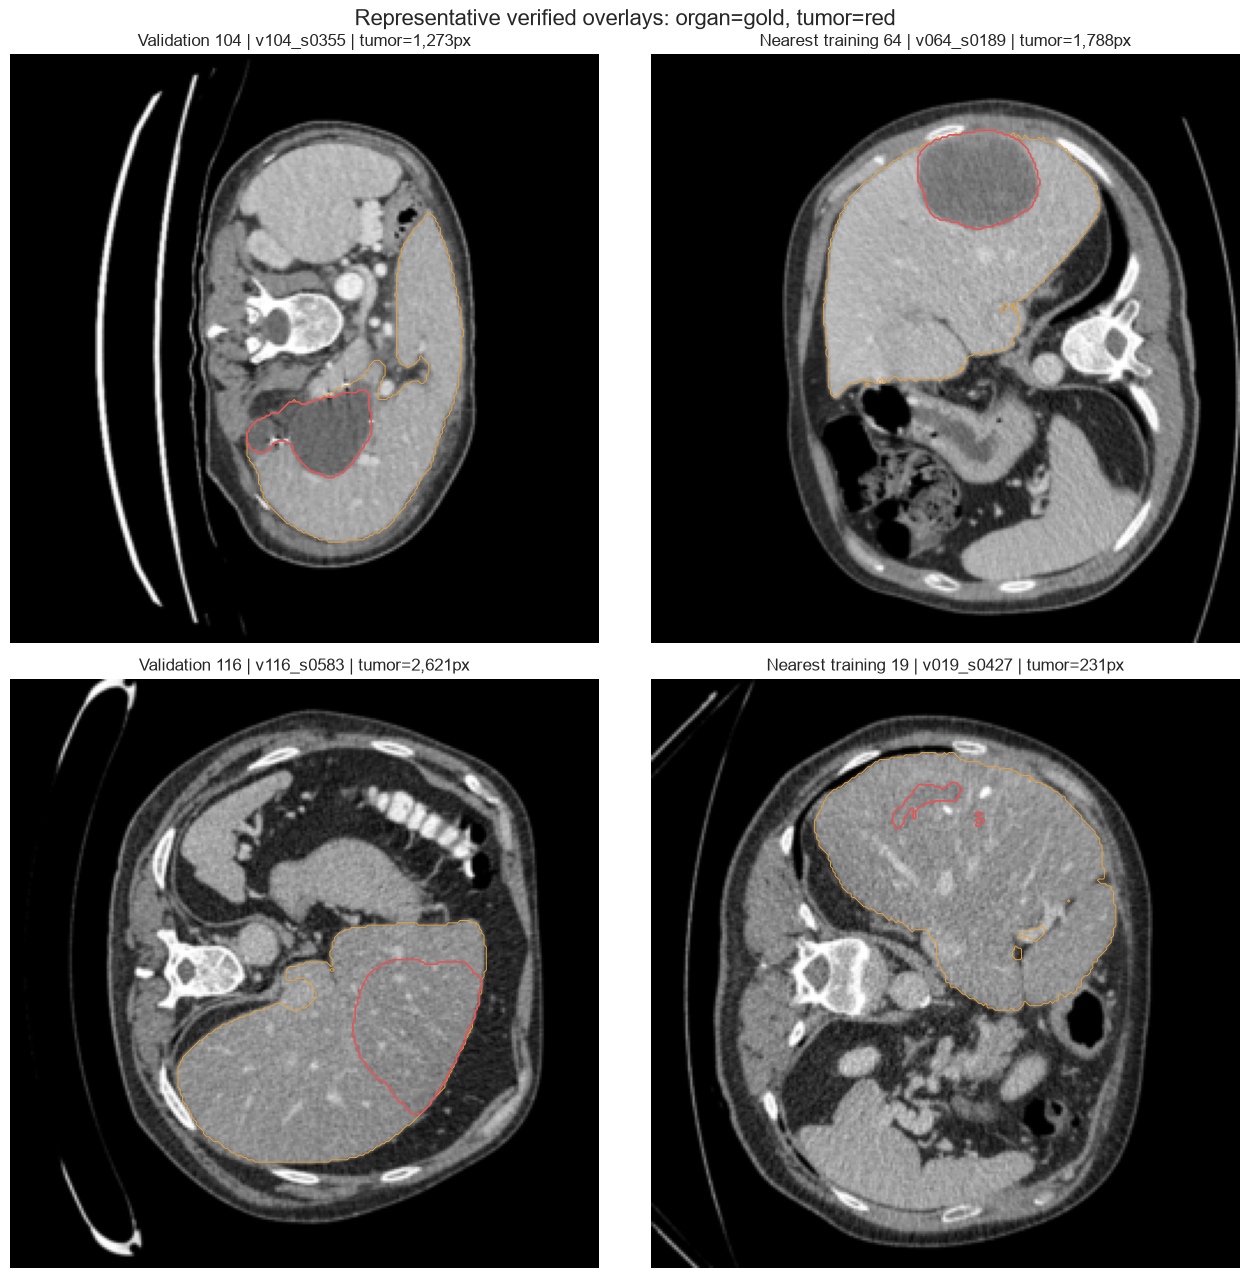

In [9]:
def representative_row(split: str, volume_id: int) -> pd.Series:
    candidates = eligible.loc[
        eligible["split"].eq(split)
        & eligible["volume_id"].eq(volume_id)
        & eligible["tumor_pixels"].gt(0)
    ]
    if candidates.empty:
        candidates = eligible.loc[
            eligible["split"].eq(split)
            & eligible["volume_id"].eq(volume_id)
            & eligible["organ_pixels"].gt(0)
        ]
    return candidates.sort_values("tumor_pixels", ascending=False).iloc[0]


montage_items = []
for validation_volume in focus_volumes:
    training_volume = int(
        nearest.loc[
            nearest["validation_volume"].eq(validation_volume)
            & nearest["rank"].eq(1),
            "training_volume",
        ].iloc[0]
    )
    montage_items.extend([
        ("val", validation_volume, f"Validation {validation_volume}"),
        ("train", training_volume, f"Nearest training {training_volume}"),
    ])

fig, axes = plt.subplots(2, 2, figsize=(13, 13))
for axis, (split, volume_id, label) in zip(axes.flat, montage_items):
    row = representative_row(split, volume_id)
    image = read_grayscale(resolve_path(row["image_path"]))
    organ = read_grayscale(resolve_path(row["organ_mask_path"])) > 0
    tumor = read_grayscale(resolve_path(row["tumor_mask_path"])) > 0
    axis.imshow(image, cmap="gray")
    if organ.any():
        axis.contour(organ, levels=[0.5], colors=["#E6A23C"], linewidths=0.7)
    if tumor.any():
        axis.contour(tumor, levels=[0.5], colors=["#E15759"], linewidths=1.2)
    axis.set_title(f"{label} | {row['sample_id']} | tumor={int(row['tumor_pixels']):,}px")
    axis.axis("off")

fig.suptitle("Representative verified overlays: organ=gold, tumor=red", fontsize=16)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "focus_volume_nearest_train_overlays.png", dpi=170, bbox_inches="tight")
plt.show()


## Takeaways

### 9. Produce the evidence-based next-step gate

In [10]:
focus = analysis.loc[analysis["volume_id"].isin(focus_volumes)].copy()
focus_outliers = focus.loc[focus["appearance_outlier"], "volume_id"].astype(int).tolist()
any_focus_outlier = bool(focus_outliers)

if any_focus_outlier:
    recommendation = (
        "Run a controlled robust-intensity experiment: per-slice liver z-score "
        "normalization plus bounded gamma/noise augmentation, keeping the "
        "Focal-Dice baseline loss and sampler fixed."
    )
    next_notebook_type = "intensity_normalization_augmentation_ablation"
else:
    recommendation = (
        "Appearance shift does not explain the key failures. Keep the Focal-Dice "
        "baseline and test 2.5D adjacent-slice context as the next controlled change."
    )
    next_notebook_type = "2_5d_context_ablation"

diagnostic_result = {
    "status": "diagnostic_complete",
    "manifest_sha256": manifest_hash,
    "training_volumes": int(training["volume_id"].nunique()),
    "validation_volumes": int(validation["volume_id"].nunique()),
    "sampled_slices": int(len(sampled_manifest)),
    "shift_threshold_training_p95": shift_threshold,
    "volume_104_shift_score": float(focus.loc[focus["volume_id"].eq(104), "shift_score"].iloc[0]),
    "volume_116_shift_score": float(focus.loc[focus["volume_id"].eq(116), "shift_score"].iloc[0]),
    "focus_appearance_outliers": focus_outliers,
    "next_notebook_type": next_notebook_type,
    "recommendation": recommendation,
    "test_images_accessed": False,
}
(OUTPUT_DIR / "appearance_domain_gate_result.json").write_text(
    json.dumps(diagnostic_result, indent=2), encoding="utf-8"
)
display(pd.DataFrame([diagnostic_result]).T.rename(columns={0: "result"}))
print(recommendation)


,result
status,diagnostic_complete
manifest_sha256,575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63...
training_volumes,104
validation_volumes,13
sampled_slices,3106
shift_threshold_training_p95,6.402177
volume_104_shift_score,6.67683
volume_116_shift_score,3.739819
focus_appearance_outliers,[104]
next_notebook_type,intensity_normalization_augmentation_ablation


Run a controlled robust-intensity experiment: per-slice liver z-score normalization plus bounded gamma/noise augmentation, keeping the Focal-Dice baseline loss and sampler fixed.


### Interpretation guide

- A high shift score means the patient differs from the multivariate training
  appearance distribution; it does not prove that shift caused the model error.
- Histograms and nearest-volume overlays provide the qualitative check needed
  before acting on the score.
- Do not access the test split until a final protocol has been frozen.
